# Flappy Bird Experiments

Miguel Ángel Carrillo Cobián

COMP-579: Reinforcement Learning - Winter 2026

## Exploration

In [26]:
import gymnasium as gym
import flappy_bird_gymnasium
import numpy as np

env = gym.make("FlappyBird-v0", render_mode="human")

obs, info = env.reset()

print("Observation type:", type(obs))
print("Observation shape:", obs.shape)
print("Observation dtype:", obs.dtype)
print("Observation min:", np.min(obs))
print("Observation max:", np.max(obs))
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

env.close()

Observation type: <class 'numpy.ndarray'>
Observation shape: (180,)
Observation dtype: float64
Observation min: 0.8073485895858156
Observation max: 1.0000000000000002
Action space: Discrete(2)
Observation space: Box(0.0, 1.0, (180,), float64)


In [27]:
import gymnasium as gym
import flappy_bird_gymnasium
import numpy as np

NUM_EPISODES = 3
MAX_STEPS = 200

env = gym.make("FlappyBird-v0", render_mode="human")

for episode in range(NUM_EPISODES):

    obs, info = env.reset()
    done = False
    step = 0

    print("\n==============================")
    print(f"Episode {episode + 1}")
    print("==============================")

    while not done and step < MAX_STEPS:

        action = env.action_space.sample()   # random action

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        print(f"\nStep {step}")
        print("Action:", action)
        print("State:", obs)
        print("Next State:", next_obs)
        print("Reward:", reward)

        obs = next_obs
        step += 1

env.close()


Episode 1

Step 0
Action: 0
State: [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.      

### Environment Observation and Action Space

The Flappy Bird environment provides observations as a NumPy array:

- **Type:** `numpy.ndarray`
- **Shape:** `(180,)`
- **Data type:** `float64`
- **Range:** approximately `[0.80, 1.00]`
- **Observation space:** `Box(0.0, 1.0, (180,), float64)`

This means that each state is represented as a **180-dimensional continuous vector normalized between 0 and 1**.

The 180 features correspond to **ray-based visual sensors** emitted from the bird’s point of view, approximately **one ray per degree** across its field of view. Each value represents the **normalized distance to the nearest obstacle or background along that direction**, allowing the agent to perceive nearby pipes, the floor, and the ceiling.

This representation provides a **compact visual sensing model**: it captures spatial information about the environment while avoiding the high dimensionality of raw pixel inputs.

The **action space** is:

- **Type:** `Discrete(2)`
- `0` → do nothing  
- `1` → flap

Because the observation is already a compact feature vector rather than raw images, the agent can be trained using a **multilayer perceptron (MLP)** instead of a convolutional neural network.

This observation structure is well suited for reinforcement learning and allows us to compare the performance of **standard DQN** and **Deep Q-learning from Demonstrations (DQfD)** using the same state representation.

## DQN Calibration

In [28]:
import random
from collections import deque, namedtuple

import gymnasium as gym
import flappy_bird_gymnasium
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def preprocess_obs(obs):
    """
    Downsample the 180-ray observation to 90 rays.
    Converts to float32 for PyTorch.
    """
    obs = np.asarray(obs, dtype=np.float32)
    obs = obs[::2]   # 180 -> 90
    return obs

class DQN(nn.Module):
    def __init__(self, state_dim=90, n_actions=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)
    

Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = np.array([t.state for t in batch], dtype=np.float32)
        actions = np.array([t.action for t in batch], dtype=np.int64)
        rewards = np.array([t.reward for t in batch], dtype=np.float32)
        next_states = np.array([t.next_state for t in batch], dtype=np.float32)
        dones = np.array([t.done for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)
    



def select_action(state, q_network, epsilon, n_actions=2):
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())



def train_step(q_network, target_network, replay_buffer, optimizer, batch_size, gamma):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    current_q = q_network(states).gather(1, actions)

    with torch.no_grad():
        max_next_q = target_network(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + gamma * max_next_q * (1.0 - dones)

    loss = nn.MSELoss()(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


def train_dqn(
    num_episodes=500,
    max_steps_per_episode=1000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=50000,
    min_buffer_size=1000,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
):
    env = gym.make("FlappyBird-v0", render_mode=None)

    state_dim = 90
    n_actions = env.action_space.n

    q_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(q_network.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(buffer_capacity)

    epsilon = epsilon_start

    episode_rewards = []
    losses = []

    for episode in range(num_episodes):
        obs, info = env.reset()
        state = preprocess_obs(obs)

        done = False
        total_reward = 0.0
        episode_loss_values = []

        for step in range(max_steps_per_episode):
            action = select_action(state, q_network, epsilon, n_actions)

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            next_state = preprocess_obs(next_obs)

            replay_buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(replay_buffer) >= min_buffer_size:
                loss = train_step(
                    q_network=q_network,
                    target_network=target_network,
                    replay_buffer=replay_buffer,
                    optimizer=optimizer,
                    batch_size=batch_size,
                    gamma=gamma,
                )
                if loss is not None:
                    episode_loss_values.append(loss)

            if done:
                break

        episode_rewards.append(total_reward)

        if episode_loss_values:
            losses.append(np.mean(episode_loss_values))
        else:
            losses.append(np.nan)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episode + 1) % target_update_freq == 0:
            target_network.load_state_dict(q_network.state_dict())

        if (episode + 1) % 10 == 0:
            recent_rewards = episode_rewards[-10:]
            print(
                f"Episode {episode + 1:4d} | "
                f"Avg Reward (last 10): {np.mean(recent_rewards):7.3f} | "
                f"Epsilon: {epsilon:6.3f}"
            )

    env.close()
    return q_network, target_network, episode_rewards, losses


q_network, target_network, episode_rewards, losses = train_dqn(
    num_episodes=100,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
)


Using device: cpu
Episode   10 | Avg Reward (last 10):  -7.500 | Epsilon:  0.951
Episode   20 | Avg Reward (last 10):  -7.560 | Epsilon:  0.905
Episode   30 | Avg Reward (last 10):  -7.860 | Epsilon:  0.860
Episode   40 | Avg Reward (last 10):  -7.200 | Epsilon:  0.818
Episode   50 | Avg Reward (last 10):  -7.020 | Epsilon:  0.778
Episode   60 | Avg Reward (last 10):  -7.320 | Epsilon:  0.740
Episode   70 | Avg Reward (last 10):  -7.020 | Epsilon:  0.704
Episode   80 | Avg Reward (last 10):  -6.840 | Epsilon:  0.670
Episode   90 | Avg Reward (last 10):  -6.840 | Epsilon:  0.637
Episode  100 | Avg Reward (last 10):  -6.900 | Epsilon:  0.606


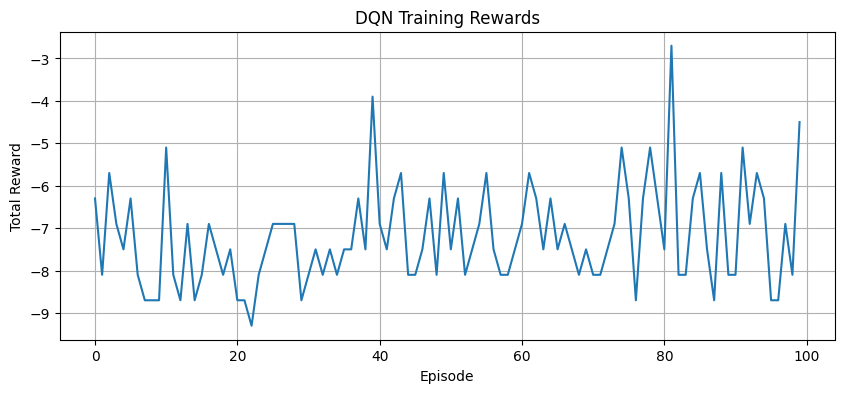

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Training Rewards")
plt.grid(True)
plt.show()

In [30]:
def evaluate_policy(q_network, num_episodes=5, max_steps_per_episode=1000, render_mode="human"):
    env = gym.make("FlappyBird-v0", render_mode=render_mode)

    rewards = []

    for episode in range(num_episodes):
        obs, info = env.reset()
        state = preprocess_obs(obs)
        done = False
        total_reward = 0.0

        for step in range(max_steps_per_episode):
            state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                action = int(torch.argmax(q_network(state_tensor), dim=1).item())

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            state = preprocess_obs(next_obs)
            total_reward += reward

            if done:
                break

        rewards.append(total_reward)
        print(f"Evaluation episode {episode + 1}: reward = {total_reward:.2f}")

    env.close()
    print("Average evaluation reward:", np.mean(rewards))
    return rewards

In [31]:
eval_rewards = evaluate_policy(q_network, num_episodes=3, render_mode="human")

Evaluation episode 1: reward = -0.90
Evaluation episode 2: reward = -5.70
Evaluation episode 3: reward = -6.30
Average evaluation reward: -4.299999999999998


### Simplification of state representation

To simplify the state representation, we may reduce the observation from 180 rays to 90 rays by downsampling the ray vector.

## Experimentation

### BASELINE DQN

In [32]:
import os
import pickle
import random
from collections import deque, namedtuple

import gymnasium as gym
import flappy_bird_gymnasium
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def preprocess_obs(obs):
    """
    Downsample the 180-ray observation to 90 rays.
    Converts to float32 for PyTorch.
    """
    obs = np.asarray(obs, dtype=np.float32)
    obs = obs[::2]   # 180 -> 90
    return obs


class DQN(nn.Module):
    def __init__(self, state_dim=90, n_actions=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)


Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = np.array([t.state for t in batch], dtype=np.float32)
        actions = np.array([t.action for t in batch], dtype=np.int64)
        rewards = np.array([t.reward for t in batch], dtype=np.float32)
        next_states = np.array([t.next_state for t in batch], dtype=np.float32)
        dones = np.array([t.done for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


def select_action(state, q_network, epsilon, n_actions=2):
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())


def train_step(q_network, target_network, replay_buffer, optimizer, batch_size, gamma):
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    current_q = q_network(states).gather(1, actions)

    with torch.no_grad():
        max_next_q = target_network(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + gamma * max_next_q * (1.0 - dones)

    loss = nn.MSELoss()(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


def train_dqn(
    seed,
    num_episodes=500,
    max_steps_per_episode=1000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=50000,
    min_buffer_size=1000,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.995,
):
    set_seed(seed)

    env = gym.make("FlappyBird-v0", render_mode=None)

    state_dim = 90
    n_actions = env.action_space.n

    q_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network = DQN(state_dim=state_dim, n_actions=n_actions).to(device)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(q_network.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(buffer_capacity)

    epsilon = epsilon_start

    episode_rewards = []
    losses = []
    epsilons = []

    for episode in range(num_episodes):
        obs, info = env.reset(seed=seed + episode)
        state = preprocess_obs(obs)

        done = False
        total_reward = 0.0
        episode_loss_values = []

        for step in range(max_steps_per_episode):
            action = select_action(state, q_network, epsilon, n_actions)

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            next_state = preprocess_obs(next_obs)

            replay_buffer.push(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward

            if len(replay_buffer) >= min_buffer_size:
                loss = train_step(
                    q_network=q_network,
                    target_network=target_network,
                    replay_buffer=replay_buffer,
                    optimizer=optimizer,
                    batch_size=batch_size,
                    gamma=gamma,
                )
                if loss is not None:
                    episode_loss_values.append(loss)

            if done:
                break

        episode_rewards.append(total_reward)
        epsilons.append(epsilon)

        if episode_loss_values:
            losses.append(float(np.mean(episode_loss_values)))
        else:
            losses.append(np.nan)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episode + 1) % target_update_freq == 0:
            target_network.load_state_dict(q_network.state_dict())

        if (episode + 1) % 10 == 0:
            recent_rewards = episode_rewards[-10:]
            print(
                f"[Seed {seed}] Episode {episode + 1:4d} | "
                f"Avg Reward (last 10): {np.mean(recent_rewards):7.3f} | "
                f"Epsilon: {epsilon:6.3f}"
            )

    env.close()

    return {
        "seed": seed,
        "episode_rewards": episode_rewards,
        "losses": losses,
        "epsilons": epsilons,
        "final_epsilon": epsilon,
        "q_network_state_dict": q_network.state_dict(),
        "target_network_state_dict": target_network.state_dict(),
    }


def run_experiment(seeds, save_dir="dqn_results", save_models=True, **train_kwargs):
    os.makedirs(save_dir, exist_ok=True)

    all_results = {
        "seeds": list(seeds),
        "config": train_kwargs,
        "runs": []
    }

    for seed in seeds:
        print(f"\n{'='*70}")
        print(f"Starting training for seed {seed}")
        print(f"{'='*70}")

        run_result = train_dqn(seed=seed, **train_kwargs)
        all_results["runs"].append(
            {
                "seed": run_result["seed"],
                "episode_rewards": run_result["episode_rewards"],
                "losses": run_result["losses"],
                "epsilons": run_result["epsilons"],
                "final_epsilon": run_result["final_epsilon"],
            }
        )

        if save_models:
            torch.save(
                run_result["q_network_state_dict"],
                os.path.join(save_dir, f"q_network_seed_{seed}.pt")
            )
            torch.save(
                run_result["target_network_state_dict"],
                os.path.join(save_dir, f"target_network_seed_{seed}.pt")
            )

    rewards_array = np.array([run["episode_rewards"] for run in all_results["runs"]], dtype=np.float32)
    losses_array = np.array([run["losses"] for run in all_results["runs"]], dtype=np.float32)

    all_results["summary"] = {
        "mean_episode_rewards": np.mean(rewards_array, axis=0),
        "std_episode_rewards": np.std(rewards_array, axis=0),
        "mean_losses": np.nanmean(losses_array, axis=0),
        "std_losses": np.nanstd(losses_array, axis=0),
    }

    with open(os.path.join(save_dir, "training_results.pkl"), "wb") as f:
        pickle.dump(all_results, f)

    np.save(os.path.join(save_dir, "mean_episode_rewards.npy"), all_results["summary"]["mean_episode_rewards"])
    np.save(os.path.join(save_dir, "std_episode_rewards.npy"), all_results["summary"]["std_episode_rewards"])
    np.save(os.path.join(save_dir, "mean_losses.npy"), all_results["summary"]["mean_losses"])
    np.save(os.path.join(save_dir, "std_losses.npy"), all_results["summary"]["std_losses"])

    return all_results


# Run across 3 seeds
seeds = [42, 123, 999]

results = run_experiment(
    seeds=seeds,
    save_dir="dqn_flappy_3seeds",
    save_models=True,
    num_episodes=1500,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,
    target_update_freq=10,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
)

print("\nFinished training across all seeds.")
print("Saved results to: dqn_flappy_3seeds")

Using device: cpu

Starting training for seed 42
[Seed 42] Episode   10 | Avg Reward (last 10):  -7.500 | Epsilon:  0.951
[Seed 42] Episode   20 | Avg Reward (last 10):  -7.560 | Epsilon:  0.905
[Seed 42] Episode   30 | Avg Reward (last 10):  -8.040 | Epsilon:  0.860
[Seed 42] Episode   40 | Avg Reward (last 10):  -7.560 | Epsilon:  0.818
[Seed 42] Episode   50 | Avg Reward (last 10):  -7.320 | Epsilon:  0.778
[Seed 42] Episode   60 | Avg Reward (last 10):  -7.080 | Epsilon:  0.740
[Seed 42] Episode   70 | Avg Reward (last 10):  -6.900 | Epsilon:  0.704
[Seed 42] Episode   80 | Avg Reward (last 10):  -6.780 | Epsilon:  0.670
[Seed 42] Episode   90 | Avg Reward (last 10):  -6.120 | Epsilon:  0.637
[Seed 42] Episode  100 | Avg Reward (last 10):  -5.760 | Epsilon:  0.606
[Seed 42] Episode  110 | Avg Reward (last 10):  -5.400 | Epsilon:  0.576
[Seed 42] Episode  120 | Avg Reward (last 10):  -5.160 | Epsilon:  0.548
[Seed 42] Episode  130 | Avg Reward (last 10):  -4.980 | Epsilon:  0.521
[S

C:\Users\mikel\AppData\Local\Temp\ipykernel_19148\3800364307.py:259: RuntimeWarning: Mean of empty slice
  "mean_losses": np.nanmean(losses_array, axis=0),
d:\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### DGFD: 10 EPISODES

In [33]:
import os
import pickle
import random
from collections import deque, namedtuple

import gymnasium as gym
import flappy_bird_gymnasium
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# Device / reproducibility
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# Observation preprocessing: 180 -> 90 rays
# ============================================================

def preprocess_obs(obs):
    obs = np.asarray(obs, dtype=np.float32)
    return obs[::2]   # 180 -> 90


# ============================================================
# Q-network
# ============================================================

class DQN(nn.Module):
    def __init__(self, state_dim=90, n_actions=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Prioritized Replay Buffer with demo retention
# ============================================================

Transition = namedtuple(
    "Transition",
    [
        "state",
        "action",
        "reward",
        "next_state",
        "done",
        "n_step_reward",
        "n_step_next_state",
        "n_step_done",
        "is_demo",
    ],
)


class PrioritizedReplayBuffer:
    """
    Simple proportional prioritized replay buffer.

    Key DQfD behaviors:
    - demo data can be marked permanent so it is never overwritten
    - each sample has a priority
    - importance sampling weights are returned
    """

    def __init__(self, capacity, alpha=0.6, demo_epsilon=1.0):
        self.capacity = capacity
        self.alpha = alpha
        self.demo_epsilon = demo_epsilon

        self.storage = []
        self.priorities = []

        self.demo_size = 0        # permanent region [0, demo_size)
        self.next_idx = 0         # write pointer for non-demo region

    def __len__(self):
        return len(self.storage)

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done,
        n_step_reward,
        n_step_next_state,
        n_step_done,
        is_demo=False,
        priority=None,
    ):
        transition = Transition(
            state=state,
            action=int(action),
            reward=float(reward),
            next_state=next_state,
            done=bool(done),
            n_step_reward=float(n_step_reward),
            n_step_next_state=n_step_next_state,
            n_step_done=bool(n_step_done),
            is_demo=bool(is_demo),
        )

        if priority is None:
            max_prio = max(self.priorities) if self.priorities else 1.0
            priority = max_prio

        if is_demo:
            # demos are inserted first and retained permanently
            self.storage.append(transition)
            self.priorities.append(float(priority) + self.demo_epsilon)
            self.demo_size += 1
            self.next_idx = self.demo_size
            return

        # online data overwrites only the non-demo region
        if len(self.storage) < self.capacity:
            self.storage.append(transition)
            self.priorities.append(float(priority))
        else:
            if self.demo_size >= self.capacity:
                raise ValueError("Replay buffer capacity is too small to hold permanent demos.")

            idx = self.next_idx
            if idx < self.demo_size:
                idx = self.demo_size

            self.storage[idx] = transition
            self.priorities[idx] = float(priority)

            self.next_idx += 1
            if self.next_idx >= self.capacity:
                self.next_idx = self.demo_size

    def sample(self, batch_size, beta=0.4):
        if len(self.storage) < batch_size:
            return None

        priorities = np.asarray(self.priorities, dtype=np.float64)
        scaled = priorities ** self.alpha
        probs = scaled / scaled.sum()

        indices = np.random.choice(len(self.storage), size=batch_size, replace=False, p=probs)
        samples = [self.storage[i] for i in indices]

        # importance-sampling weights
        N = len(self.storage)
        weights = (N * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = {
            "indices": indices,
            "weights": np.asarray(weights, dtype=np.float32),
            "states": np.asarray([t.state for t in samples], dtype=np.float32),
            "actions": np.asarray([t.action for t in samples], dtype=np.int64),
            "rewards": np.asarray([t.reward for t in samples], dtype=np.float32),
            "next_states": np.asarray([t.next_state for t in samples], dtype=np.float32),
            "dones": np.asarray([t.done for t in samples], dtype=np.float32),
            "n_step_rewards": np.asarray([t.n_step_reward for t in samples], dtype=np.float32),
            "n_step_next_states": np.asarray([t.n_step_next_state for t in samples], dtype=np.float32),
            "n_step_dones": np.asarray([t.n_step_done for t in samples], dtype=np.float32),
            "is_demo": np.asarray([t.is_demo for t in samples], dtype=np.float32),
        }
        return batch

    def update_priorities(self, indices, priorities):
        for idx, prio in zip(indices, priorities):
            bonus = self.demo_epsilon if self.storage[idx].is_demo else 0.0
            self.priorities[idx] = float(max(prio, 1e-6) + bonus)


# ============================================================
# Action selection
# ============================================================

def select_action(state, q_network, epsilon, n_actions=2):
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_network(state_tensor)
    return int(torch.argmax(q_values, dim=1).item())


# ============================================================
# N-step utilities
# ============================================================

def build_n_step_episode(episode, n_step=10, gamma=0.99):
    """
    episode: list of dicts with keys
      state, action, reward, next_state, done

    returns a new list where each transition includes n-step targets.
    """
    processed = []
    T = len(episode)

    for i in range(T):
        cumulative_reward = 0.0
        final_next_state = episode[i]["next_state"]
        final_done = episode[i]["done"]

        for k in range(n_step):
            j = i + k
            if j >= T:
                break

            cumulative_reward += (gamma ** k) * float(episode[j]["reward"])
            final_next_state = episode[j]["next_state"]
            final_done = bool(episode[j]["done"])

            if final_done:
                break

        processed.append(
            {
                "state": episode[i]["state"],
                "action": int(episode[i]["action"]),
                "reward": float(episode[i]["reward"]),
                "next_state": episode[i]["next_state"],
                "done": bool(episode[i]["done"]),
                "n_step_reward": float(cumulative_reward),
                "n_step_next_state": final_next_state,
                "n_step_done": final_done,
            }
        )

    return processed


# ============================================================
# Demo loading
# ============================================================

def load_demo_episodes(
    demo_file,
    num_demo_episodes,
    n_step=10,
    gamma=0.99,
    random_selection=False,
):
    with open(demo_file, "rb") as f:
        all_episodes = pickle.load(f)

    if num_demo_episodes > len(all_episodes):
        raise ValueError(
            f"Requested {num_demo_episodes} demo episodes, but file contains {len(all_episodes)}."
        )

    if random_selection:
        selected_indices = random.sample(range(len(all_episodes)), num_demo_episodes)
        selected = [all_episodes[i] for i in selected_indices]
    else:
        selected_indices = list(range(num_demo_episodes))
        selected = all_episodes[:num_demo_episodes]

    processed_episodes = []

    for ep in selected:
        clean_ep = []
        for tr in ep:
            clean_ep.append(
                {
                    "state": preprocess_obs(tr["state"]),
                    "action": int(tr["action"]),
                    "reward": float(tr["reward"]),
                    "next_state": preprocess_obs(tr["next_state"]),
                    "done": bool(tr["done"]),
                }
            )
        processed_episodes.append(build_n_step_episode(clean_ep, n_step=n_step, gamma=gamma))

    return processed_episodes, selected_indices


def add_demo_data_to_buffer(replay_buffer, demo_episodes):
    num_transitions = 0
    episode_lengths = []

    for ep in demo_episodes:
        episode_lengths.append(len(ep))
        for tr in ep:
            replay_buffer.add(
                state=tr["state"],
                action=tr["action"],
                reward=tr["reward"],
                next_state=tr["next_state"],
                done=tr["done"],
                n_step_reward=tr["n_step_reward"],
                n_step_next_state=tr["n_step_next_state"],
                n_step_done=tr["n_step_done"],
                is_demo=True,
                priority=1.0,
            )
            num_transitions += 1

    return {
        "num_demo_episodes_used": len(demo_episodes),
        "num_demo_transitions": num_transitions,
        "episode_lengths": episode_lengths,
    }


# ============================================================
# DQfD loss
# ============================================================

def large_margin_supervised_loss(q_values, expert_actions, is_demo_mask, margin=0.8):
    """
    DQfD classification-style large-margin loss:
      J_E = max_a [Q(s,a) + l(a_E, a)] - Q(s, a_E)
    where l(a_E, a)=0 if a=a_E else margin
    Applied only to demo samples.
    """
    if is_demo_mask.sum().item() == 0:
        return torch.tensor(0.0, device=q_values.device)

    actions = expert_actions.view(-1, 1)
    batch_size, n_actions = q_values.shape

    margins = torch.full_like(q_values, fill_value=margin)
    margins.scatter_(1, actions, 0.0)

    margin_q = q_values + margins
    max_margin_q, _ = margin_q.max(dim=1)

    expert_q = q_values.gather(1, actions).squeeze(1)
    per_sample = max_margin_q - expert_q

    demo_losses = per_sample * is_demo_mask
    return demo_losses.sum() / is_demo_mask.sum().clamp(min=1.0)


def dqfd_train_step(
    q_network,
    target_network,
    replay_buffer,
    optimizer,
    batch_size,
    gamma=0.99,
    n_step=10,
    beta=0.4,
    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
):
    batch = replay_buffer.sample(batch_size, beta=beta)
    if batch is None:
        return None

    states = torch.tensor(batch["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(batch["actions"], dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(batch["rewards"], dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(batch["next_states"], dtype=torch.float32, device=device)
    dones = torch.tensor(batch["dones"], dtype=torch.float32, device=device).unsqueeze(1)

    n_step_rewards = torch.tensor(batch["n_step_rewards"], dtype=torch.float32, device=device).unsqueeze(1)
    n_step_next_states = torch.tensor(batch["n_step_next_states"], dtype=torch.float32, device=device)
    n_step_dones = torch.tensor(batch["n_step_dones"], dtype=torch.float32, device=device).unsqueeze(1)

    is_demo = torch.tensor(batch["is_demo"], dtype=torch.float32, device=device)
    weights = torch.tensor(batch["weights"], dtype=torch.float32, device=device).unsqueeze(1)

    q_values = q_network(states)
    current_q = q_values.gather(1, actions)

    with torch.no_grad():
        if use_double_dqn:
            next_actions_1 = q_network(next_states).argmax(dim=1, keepdim=True)
            next_q_1 = target_network(next_states).gather(1, next_actions_1)

            next_actions_n = q_network(n_step_next_states).argmax(dim=1, keepdim=True)
            next_q_n = target_network(n_step_next_states).gather(1, next_actions_n)
        else:
            next_q_1 = target_network(next_states).max(dim=1, keepdim=True)[0]
            next_q_n = target_network(n_step_next_states).max(dim=1, keepdim=True)[0]

        target_1 = rewards + gamma * next_q_1 * (1.0 - dones)
        target_n = n_step_rewards + (gamma ** n_step) * next_q_n * (1.0 - n_step_dones)

    td_error_1 = current_q - target_1
    td_error_n = current_q - target_n

    loss_1 = (weights * td_error_1.pow(2)).mean()
    loss_n = (weights * td_error_n.pow(2)).mean()
    loss_je = large_margin_supervised_loss(
        q_values=q_values,
        expert_actions=actions.squeeze(1),
        is_demo_mask=is_demo,
        margin=margin,
    )

    l2_reg = torch.tensor(0.0, device=device)
    for p in q_network.parameters():
        l2_reg = l2_reg + p.pow(2).sum()

    total_loss = (
        lambda_dq * loss_1
        + lambda_n * loss_n
        + lambda_je * loss_je
        + lambda_l2 * l2_reg
    )

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    # priority update: |delta_1| + |delta_n|
    with torch.no_grad():
        priorities = (
            td_error_1.abs().squeeze(1).cpu().numpy()
            + td_error_n.abs().squeeze(1).cpu().numpy()
        )
        replay_buffer.update_priorities(batch["indices"], priorities)

    return {
        "total_loss": float(total_loss.item()),
        "loss_1step": float(loss_1.item()),
        "loss_nstep": float(loss_n.item()),
        "loss_margin": float(loss_je.item()),
        "mean_priority": float(np.mean(priorities)),
    }


# ============================================================
# Online episode collection with n-step bookkeeping
# ============================================================

def add_online_episode_to_buffer(replay_buffer, episode_transitions, n_step=10, gamma=0.99):
    processed = build_n_step_episode(episode_transitions, n_step=n_step, gamma=gamma)
    for tr in processed:
        replay_buffer.add(
            state=tr["state"],
            action=tr["action"],
            reward=tr["reward"],
            next_state=tr["next_state"],
            done=tr["done"],
            n_step_reward=tr["n_step_reward"],
            n_step_next_state=tr["n_step_next_state"],
            n_step_done=tr["n_step_done"],
            is_demo=False,
            priority=1.0,
        )


# ============================================================
# Full DQfD training
# ============================================================

def train_dqfd(
    seed,
    demo_file="flappybird_human_demos1.pkl",
    num_demo_episodes=10,
    num_episodes=500,
    max_steps_per_episode=1000,
    pretrain_steps=1000,
    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=50000,
    min_buffer_size=500,
    target_update_freq=1000,       # gradient steps
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,
    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
):
    set_seed(seed)

    env = gym.make("FlappyBird-v0", render_mode=None)

    q_network = DQN(state_dim=90, n_actions=env.action_space.n).to(device)
    target_network = DQN(state_dim=90, n_actions=env.action_space.n).to(device)
    target_network.load_state_dict(q_network.state_dict())
    target_network.eval()

    optimizer = optim.Adam(q_network.parameters(), lr=lr)

    replay_buffer = PrioritizedReplayBuffer(
        capacity=buffer_capacity,
        alpha=per_alpha,
        demo_epsilon=1.0,
    )

    # ---- load and retain demonstrations
    demo_episodes, selected_demo_indices = load_demo_episodes(
        demo_file=demo_file,
        num_demo_episodes=num_demo_episodes,
        n_step=n_step,
        gamma=gamma,
        random_selection=True,
    )

    demo_stats = add_demo_data_to_buffer(replay_buffer, demo_episodes)
    demo_stats["selected_demo_indices"] = selected_demo_indices

    print(
        f"Loaded {demo_stats['num_demo_episodes_used']} demo episodes "
        f"({demo_stats['num_demo_transitions']} transitions)."
    )

    # ---- pretraining on demo data only
    pretrain_logs = []
    gradient_updates = 0

    if pretrain_steps > 0:
        print(f"Starting DQfD pretraining for {pretrain_steps} steps...")
        for step in range(pretrain_steps):
            beta = per_beta_start + (per_beta_end - per_beta_start) * (step / max(pretrain_steps - 1, 1))

            log = dqfd_train_step(
                q_network=q_network,
                target_network=target_network,
                replay_buffer=replay_buffer,
                optimizer=optimizer,
                batch_size=batch_size,
                gamma=gamma,
                n_step=n_step,
                beta=beta,
                lambda_dq=lambda_dq,
                lambda_n=lambda_n,
                lambda_je=lambda_je,
                lambda_l2=lambda_l2,
                margin=margin,
                use_double_dqn=use_double_dqn,
            )

            if log is not None:
                pretrain_logs.append(log)
                gradient_updates += 1

            if gradient_updates % target_update_freq == 0:
                target_network.load_state_dict(q_network.state_dict())

            if (step + 1) % 100 == 0:
                print(
                    f"Pretrain {step + 1:4d}/{pretrain_steps} | "
                    f"total={log['total_loss']:.4f} | "
                    f"1step={log['loss_1step']:.4f} | "
                    f"nstep={log['loss_nstep']:.4f} | "
                    f"margin={log['loss_margin']:.4f}"
                )

        target_network.load_state_dict(q_network.state_dict())
        print("Finished pretraining.")

    # ---- online training
    epsilon = epsilon_start
    episode_rewards = []
    episode_loss = []
    episode_margin_loss = []
    epsilons = []

    for episode in range(num_episodes):
        obs, info = env.reset(seed=seed + episode)
        state = preprocess_obs(obs)

        done = False
        total_reward = 0.0
        online_episode = []
        logs_this_episode = []

        for step in range(max_steps_per_episode):
            action = select_action(state, q_network, epsilon, env.action_space.n)

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = preprocess_obs(next_obs)

            online_episode.append(
                {
                    "state": state,
                    "action": action,
                    "reward": reward,
                    "next_state": next_state,
                    "done": done,
                }
            )

            state = next_state
            total_reward += reward

            # online updates while interacting
            if len(replay_buffer) >= min_buffer_size:
                progress = episode / max(num_episodes - 1, 1)
                beta = per_beta_start + (per_beta_end - per_beta_start) * progress

                log = dqfd_train_step(
                    q_network=q_network,
                    target_network=target_network,
                    replay_buffer=replay_buffer,
                    optimizer=optimizer,
                    batch_size=batch_size,
                    gamma=gamma,
                    n_step=n_step,
                    beta=beta,
                    lambda_dq=lambda_dq,
                    lambda_n=lambda_n,
                    lambda_je=lambda_je,
                    lambda_l2=lambda_l2,
                    margin=margin,
                    use_double_dqn=use_double_dqn,
                )
                if log is not None:
                    logs_this_episode.append(log)
                    gradient_updates += 1

                if gradient_updates % target_update_freq == 0:
                    target_network.load_state_dict(q_network.state_dict())

            if done:
                break

        # after the episode ends, compute/store n-step online transitions
        add_online_episode_to_buffer(replay_buffer, online_episode, n_step=n_step, gamma=gamma)

        episode_rewards.append(float(total_reward))
        epsilons.append(float(epsilon))

        if logs_this_episode:
            episode_loss.append(float(np.mean([x["total_loss"] for x in logs_this_episode])))
            episode_margin_loss.append(float(np.mean([x["loss_margin"] for x in logs_this_episode])))
        else:
            episode_loss.append(np.nan)
            episode_margin_loss.append(np.nan)

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if (episode + 1) % 10 == 0:
            print(
                f"[Seed {seed}] Episode {episode + 1:4d} | "
                f"AvgReward(10)={np.mean(episode_rewards[-10:]):7.3f} | "
                f"Eps={epsilon:6.3f} | "
                f"Replay={len(replay_buffer)}"
            )

    env.close()

    return {
        "seed": seed,
        "demo_stats": demo_stats,
        "episode_rewards": episode_rewards,
        "episode_loss": episode_loss,
        "episode_margin_loss": episode_margin_loss,
        "epsilons": epsilons,
        "pretrain_logs": pretrain_logs,
        "q_network_state_dict": q_network.state_dict(),
        "target_network_state_dict": target_network.state_dict(),
    }


# ============================================================
# Multi-seed experiment runner
# ============================================================

def run_dqfd_experiment(seeds, save_dir="dqfd_results", save_models=True, **train_kwargs):
    os.makedirs(save_dir, exist_ok=True)

    all_results = {
        "seeds": list(seeds),
        "config": train_kwargs,
        "runs": [],
    }

    for seed in seeds:
        print(f"\n{'=' * 80}")
        print(f"Starting DQfD training for seed {seed}")
        print(f"{'=' * 80}")

        result = train_dqfd(seed=seed, **train_kwargs)

        all_results["runs"].append(
            {
                "seed": result["seed"],
                "demo_stats": result["demo_stats"],
                "episode_rewards": result["episode_rewards"],
                "episode_loss": result["episode_loss"],
                "episode_margin_loss": result["episode_margin_loss"],
                "epsilons": result["epsilons"],
                "pretrain_logs": result["pretrain_logs"],
            }
        )

        if save_models:
            torch.save(
                result["q_network_state_dict"],
                os.path.join(save_dir, f"dqfd_q_network_seed_{seed}.pt"),
            )
            torch.save(
                result["target_network_state_dict"],
                os.path.join(save_dir, f"dqfd_target_network_seed_{seed}.pt"),
            )

    rewards_array = np.array([run["episode_rewards"] for run in all_results["runs"]], dtype=np.float32)
    losses_array = np.array([run["episode_loss"] for run in all_results["runs"]], dtype=np.float32)

    all_results["summary"] = {
        "mean_episode_rewards": np.mean(rewards_array, axis=0),
        "std_episode_rewards": np.std(rewards_array, axis=0),
        "mean_episode_loss": np.nanmean(losses_array, axis=0),
        "std_episode_loss": np.nanstd(losses_array, axis=0),
    }

    with open(os.path.join(save_dir, "dqfd_training_results.pkl"), "wb") as f:
        pickle.dump(all_results, f)

    np.save(os.path.join(save_dir, "mean_episode_rewards.npy"), all_results["summary"]["mean_episode_rewards"])
    np.save(os.path.join(save_dir, "std_episode_rewards.npy"), all_results["summary"]["std_episode_rewards"])

    return all_results

Using device: cpu


In [34]:
seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_flappy_10_3seeds",
    save_models=True,

    demo_file="flappybird_human_demos1.pkl",
    num_demo_episodes=10,     # choose 0..50
    pretrain_steps=1000,

    num_episodes=1500,
    max_steps_per_episode=1000,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,  # gradient updates
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_flappy_10_3seeds")


Starting DQfD training for seed 42
Loaded 10 demo episodes (1932 transitions).
Starting DQfD pretraining for 1000 steps...
Pretrain  100/1000 | total=1.4817 | 1step=0.1977 | nstep=1.2361 | margin=0.1574
Pretrain  200/1000 | total=1.1386 | 1step=0.2206 | nstep=0.8908 | margin=0.0881
Pretrain  300/1000 | total=1.2776 | 1step=0.2216 | nstep=1.0187 | margin=0.1213
Pretrain  400/1000 | total=1.1988 | 1step=0.2663 | nstep=0.8991 | margin=0.1085
Pretrain  500/1000 | total=0.9486 | 1step=0.1768 | nstep=0.7263 | margin=0.1486
Pretrain  600/1000 | total=0.8777 | 1step=0.2800 | nstep=0.5794 | margin=0.0576
Pretrain  700/1000 | total=0.9714 | 1step=0.2851 | nstep=0.6791 | margin=0.0205
Pretrain  800/1000 | total=1.0362 | 1step=0.2427 | nstep=0.7524 | margin=0.1337
Pretrain  900/1000 | total=0.8657 | 1step=0.1970 | nstep=0.6505 | margin=0.0573
Pretrain 1000/1000 | total=0.7126 | 1step=0.1924 | nstep=0.5020 | margin=0.0575
Finished pretraining.
[Seed 42] Episode   10 | AvgReward(10)= -7.200 | Eps= 

### DGFD: 25 EPISODES

In [35]:
seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_flappy_25_3seeds",
    save_models=True,

    demo_file="flappybird_human_demos1.pkl",
    num_demo_episodes=25,     # choose 0..50
    pretrain_steps=1000,

    num_episodes=1500,
    max_steps_per_episode=1000,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,  # gradient updates
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_flappy_25_3seeds")


Starting DQfD training for seed 42
Loaded 25 demo episodes (5079 transitions).
Starting DQfD pretraining for 1000 steps...
Pretrain  100/1000 | total=1.4132 | 1step=0.1981 | nstep=1.1844 | margin=0.0998
Pretrain  200/1000 | total=1.3446 | 1step=0.2042 | nstep=1.0762 | margin=0.2110
Pretrain  300/1000 | total=1.1857 | 1step=0.1945 | nstep=0.9253 | margin=0.2169
Pretrain  400/1000 | total=1.1660 | 1step=0.2435 | nstep=0.8639 | margin=0.1922
Pretrain  500/1000 | total=1.1030 | 1step=0.1497 | nstep=0.9188 | margin=0.1120
Pretrain  600/1000 | total=0.9630 | 1step=0.2969 | nstep=0.5775 | margin=0.2923
Pretrain  700/1000 | total=0.6641 | 1step=0.1179 | nstep=0.5179 | margin=0.0911
Pretrain  800/1000 | total=1.2378 | 1step=0.1518 | nstep=1.0249 | margin=0.2004
Pretrain  900/1000 | total=0.8774 | 1step=0.1898 | nstep=0.6766 | margin=0.0333
Pretrain 1000/1000 | total=0.7701 | 1step=0.1558 | nstep=0.5784 | margin=0.1163
Finished pretraining.
[Seed 42] Episode   10 | AvgReward(10)= -7.140 | Eps= 

### DGFD: 50 EPISODES

In [36]:
seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_flappy_50_3seeds",
    save_models=True,

    demo_file="flappybird_human_demos1.pkl",
    num_demo_episodes=50,     # choose 0..50
    pretrain_steps=1000,

    num_episodes=1500,
    max_steps_per_episode=1000,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,  # gradient updates
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_flappy_50_3seeds")


Starting DQfD training for seed 42
Loaded 50 demo episodes (9528 transitions).
Starting DQfD pretraining for 1000 steps...
Pretrain  100/1000 | total=1.2497 | 1step=0.1352 | nstep=1.0636 | margin=0.1669
Pretrain  200/1000 | total=1.3800 | 1step=0.1821 | nstep=1.1541 | margin=0.1433
Pretrain  300/1000 | total=1.3973 | 1step=0.1444 | nstep=1.1958 | margin=0.1874
Pretrain  400/1000 | total=0.8819 | 1step=0.1472 | nstep=0.7174 | margin=0.0548
Pretrain  500/1000 | total=1.0684 | 1step=0.2817 | nstep=0.7345 | margin=0.1710
Pretrain  600/1000 | total=1.0151 | 1step=0.1461 | nstep=0.8222 | margin=0.1530
Pretrain  700/1000 | total=0.9073 | 1step=0.1779 | nstep=0.6913 | margin=0.1237
Pretrain  800/1000 | total=1.0394 | 1step=0.1508 | nstep=0.8448 | margin=0.1429
Pretrain  900/1000 | total=0.9129 | 1step=0.1520 | nstep=0.7150 | margin=0.1497
Pretrain 1000/1000 | total=0.7913 | 1step=0.2601 | nstep=0.4841 | margin=0.1538
Finished pretraining.
[Seed 42] Episode   10 | AvgReward(10)= -7.680 | Eps= 

### DGFD: 01 EPISODES

In [37]:
seeds = [42, 123, 999]

results = run_dqfd_experiment(
    seeds=seeds,
    save_dir="dqfd_flappy_01_3seeds",
    save_models=True,

    demo_file="flappybird_human_demos1.pkl",
    num_demo_episodes=2,     # choose 0..50
    pretrain_steps=1000,

    num_episodes=1500,
    max_steps_per_episode=1000,

    gamma=0.99,
    n_step=10,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=20000,
    min_buffer_size=500,

    target_update_freq=1000,  # gradient updates
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,

    per_alpha=0.6,
    per_beta_start=0.4,
    per_beta_end=1.0,

    lambda_dq=1.0,
    lambda_n=1.0,
    lambda_je=0.3,
    lambda_l2=1e-5,
    margin=0.8,
    use_double_dqn=True,
)

print("\nFinished DQfD training across all seeds.")
print("Saved results to: dqfd_flappy_01_3seeds")


Starting DQfD training for seed 42
Loaded 2 demo episodes (477 transitions).
Starting DQfD pretraining for 1000 steps...
Pretrain  100/1000 | total=1.2698 | 1step=0.3049 | nstep=0.9076 | margin=0.1883
Pretrain  200/1000 | total=1.3359 | 1step=0.2776 | nstep=1.0212 | margin=0.1207
Pretrain  300/1000 | total=1.1200 | 1step=0.4278 | nstep=0.6437 | margin=0.1591
Pretrain  400/1000 | total=1.2316 | 1step=0.4947 | nstep=0.7055 | margin=0.1015
Pretrain  500/1000 | total=1.3321 | 1step=0.4151 | nstep=0.8757 | margin=0.1342
Pretrain  600/1000 | total=1.1193 | 1step=0.4383 | nstep=0.6566 | margin=0.0777
Pretrain  700/1000 | total=1.0144 | 1step=0.3997 | nstep=0.5977 | margin=0.0528
Pretrain  800/1000 | total=1.1278 | 1step=0.4979 | nstep=0.6017 | margin=0.0904
Pretrain  900/1000 | total=0.9694 | 1step=0.3593 | nstep=0.5902 | margin=0.0621
Pretrain 1000/1000 | total=0.9074 | 1step=0.3519 | nstep=0.5369 | margin=0.0583
Finished pretraining.
[Seed 42] Episode   10 | AvgReward(10)= -7.200 | Eps= 0.

C:\Users\mikel\AppData\Local\Temp\ipykernel_19148\587465071.py:737: RuntimeWarning: Mean of empty slice
  "mean_episode_loss": np.nanmean(losses_array, axis=0),


## Results Analysis

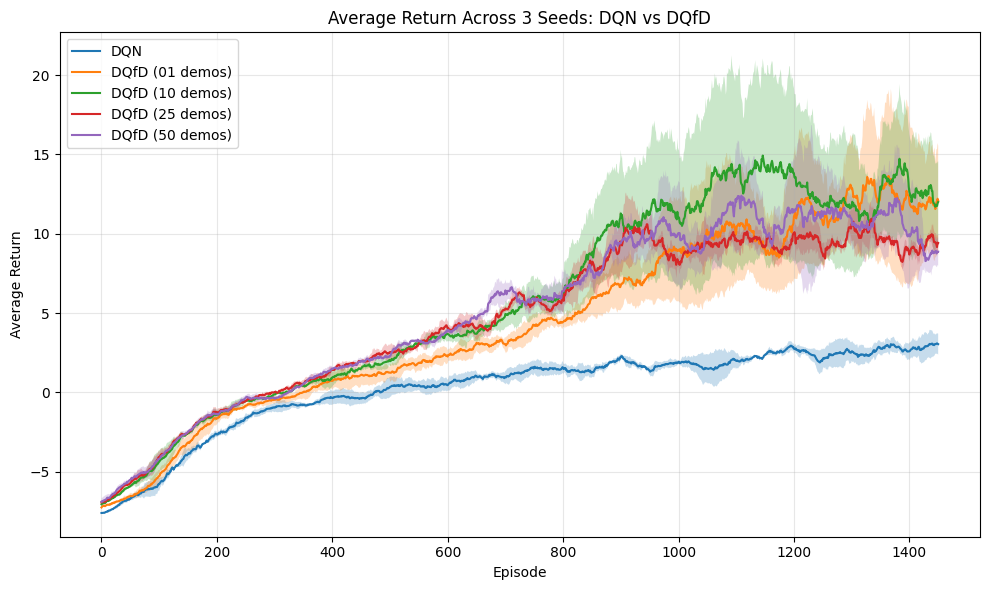

In [38]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


def load_rewards_from_results_folder(folder_path):
    """
    Load per-seed episode reward curves from a results folder containing training_results.pkl
    or dqfd_training_results.pkl.

    Returns:
        rewards_per_seed: list of lists
            One reward curve per seed.
    """
    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    if "runs" not in results:
        raise KeyError(f"'runs' key not found in {results_file}")

    rewards_per_seed = []
    for run in results["runs"]:
        if "episode_rewards" in run:
            rewards_per_seed.append(run["episode_rewards"])
        else:
            raise KeyError(f"'episode_rewards' missing in one run from {results_file}")

    return rewards_per_seed


def moving_average(x, window):
    x = np.asarray(x, dtype=np.float32)
    if window <= 1:
        return x
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_compare_smoothed_rewards(
    train_rewards_list,
    labels=None,
    window=10,
    xlabel="Episode",
    ylabel="Average Return",
    title="DQN vs DQfD",
):
    """
    Plot comparison of multiple reward curves (mean ± std across seeds).

    Args:
        train_rewards_list : list[list[list[float]]]
            Outer list over methods.
            Each element is a list over seeds,
            where each seed is a reward sequence.

        labels : list[str] or None
            Labels for each curve.

        window : int
            Moving-average smoothing window.
    """
    if labels is None:
        labels = [f"Method {i+1}" for i in range(len(train_rewards_list))]

    if len(labels) != len(train_rewards_list):
        raise ValueError("labels must match number of methods")

    def compute_stats(train_rewards):
        smoothed = [moving_average(r, window) for r in train_rewards]
        min_len = min(len(r) for r in smoothed)
        smoothed = np.array([r[:min_len] for r in smoothed], dtype=np.float32)

        avg = np.mean(smoothed, axis=0)
        std = np.std(smoothed, axis=0)
        return avg, std

    stats = [compute_stats(tr) for tr in train_rewards_list]

    min_len = min(len(avg) for avg, _ in stats)
    x = np.arange(min_len)

    plt.figure(figsize=(10, 6))

    for (avg, std), label in zip(stats, labels):
        avg = avg[:min_len]
        std = std[:min_len]

        plt.plot(x, avg, label=label)
        plt.fill_between(x, avg - std, avg + std, alpha=0.25)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Set your 4 experiment folders here
# ---------------------------------------------------------
experiment_folders = [
    "dqn_flappy_3seeds",
    "dqfd_flappy_01_3seeds",
    "dqfd_flappy_10_3seeds",
    "dqfd_flappy_25_3seeds",
    "dqfd_flappy_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load reward curves from all folders
all_rewards = [load_rewards_from_results_folder(folder) for folder in experiment_folders]

# Plot
plot_compare_smoothed_rewards(
    train_rewards_list=all_rewards,
    labels=labels,
    window=50,
    xlabel="Episode",
    ylabel="Average Return",
    title="Average Return Across 3 Seeds: DQN vs DQfD",
)

Results – Flappy Bird (AVG Return vs Episode)

In the AVG Return vs Episode plot for Flappy Bird, we can clearly observe a learning behavior across all models. However, it is evident that DQfD, in all of its variants, outperforms DQN alone.

Another interesting finding is that, before episode 1000, the worst-performing DQfD variant was the one with the fewest demonstrations. However, over time, this model gradually improves and eventually surpasses the other models during the last 500 episodes. This suggests that even with limited prior experience, DQfD can achieve strong performance given sufficient training.

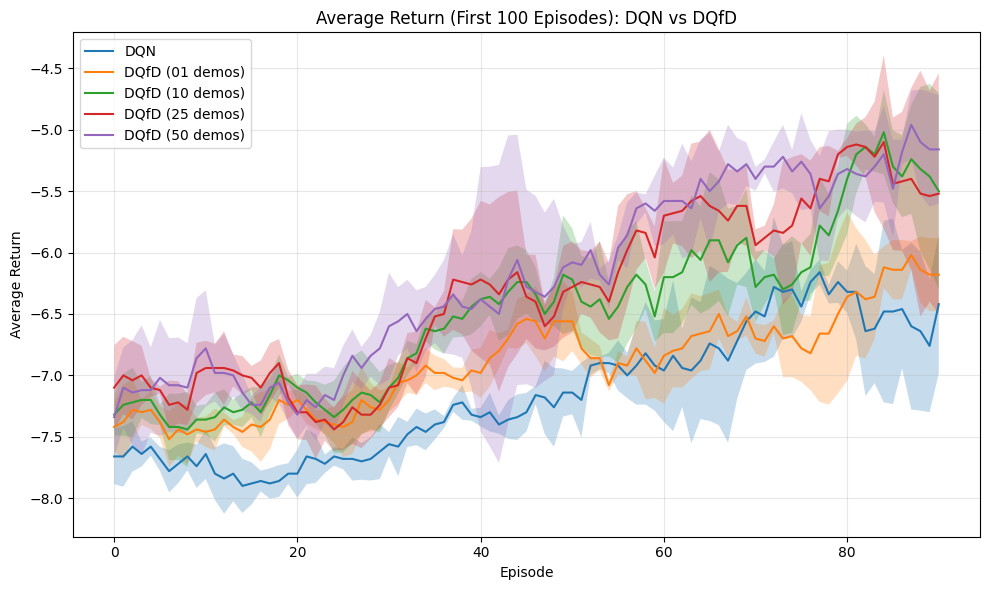

In [39]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


MAX_EPISODES = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """

    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    rewards_per_seed = []
    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[:max_episodes]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def moving_average(x, window):
    x = np.asarray(x, dtype=np.float32)

    if window <= 1:
        return x

    if len(x) < window:
        return x

    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_compare_smoothed_rewards(
    train_rewards_list,
    labels=None,
    window=10,
    xlabel="Episode",
    ylabel="Average Return",
    title="DQN vs DQfD",
):

    if labels is None:
        labels = [f"Method {i+1}" for i in range(len(train_rewards_list))]

    def compute_stats(train_rewards):

        smoothed = [moving_average(r, window) for r in train_rewards]

        min_len = min(len(r) for r in smoothed)
        smoothed = np.array([r[:min_len] for r in smoothed], dtype=np.float32)

        avg = np.mean(smoothed, axis=0)
        std = np.std(smoothed, axis=0)

        return avg, std

    stats = [compute_stats(tr) for tr in train_rewards_list]

    min_len = min(len(avg) for avg, _ in stats)
    x = np.arange(min_len)

    plt.figure(figsize=(10, 6))

    for (avg, std), label in zip(stats, labels):

        avg = avg[:min_len]
        std = std[:min_len]

        plt.plot(x, avg, label=label)
        plt.fill_between(x, avg - std, avg + std, alpha=0.25)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Set your experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_flappy_3seeds",
    "dqfd_flappy_01_3seeds",
    "dqfd_flappy_10_3seeds",
    "dqfd_flappy_25_3seeds",
    "dqfd_flappy_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load only first 100 episodes
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=MAX_EPISODES)
    for folder in experiment_folders
]

plot_compare_smoothed_rewards(
    train_rewards_list=all_rewards,
    labels=labels,
    window=10,
    xlabel="Episode",
    ylabel="Average Return",
    title="Average Return (First 100 Episodes): DQN vs DQfD",
)

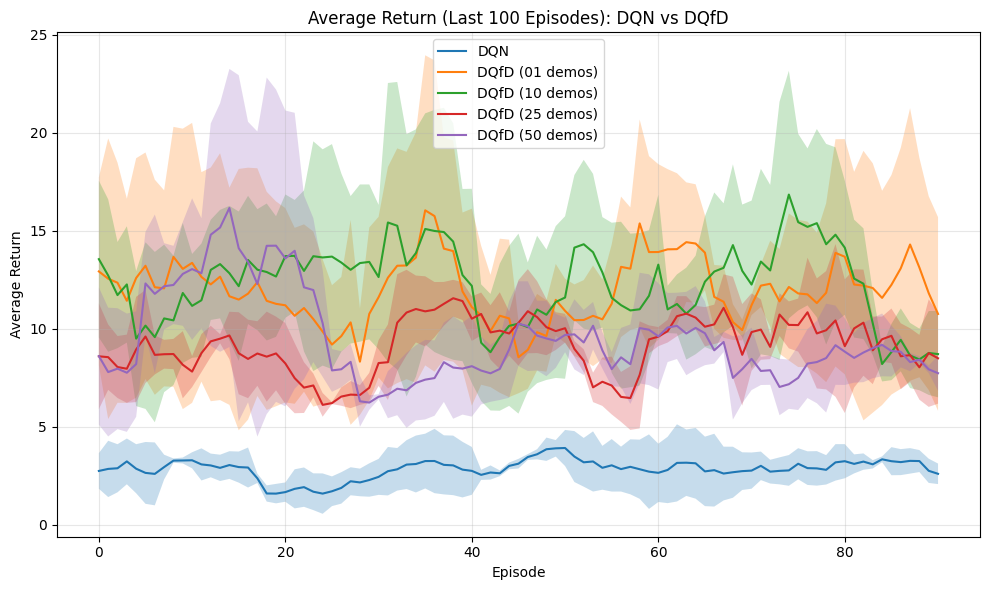

In [44]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


MAX_EPISODES = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """

    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    rewards_per_seed = []
    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[-max_episodes:]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def moving_average(x, window):
    x = np.asarray(x, dtype=np.float32)

    if window <= 1:
        return x

    if len(x) < window:
        return x

    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_compare_smoothed_rewards(
    train_rewards_list,
    labels=None,
    window=10,
    xlabel="Episode",
    ylabel="Average Return",
    title="DQN vs DQfD",
):

    if labels is None:
        labels = [f"Method {i+1}" for i in range(len(train_rewards_list))]

    def compute_stats(train_rewards):

        smoothed = [moving_average(r, window) for r in train_rewards]

        min_len = min(len(r) for r in smoothed)
        smoothed = np.array([r[:min_len] for r in smoothed], dtype=np.float32)

        avg = np.mean(smoothed, axis=0)
        std = np.std(smoothed, axis=0)

        return avg, std

    stats = [compute_stats(tr) for tr in train_rewards_list]

    min_len = min(len(avg) for avg, _ in stats)
    x = np.arange(min_len)

    plt.figure(figsize=(10, 6))

    for (avg, std), label in zip(stats, labels):

        avg = avg[:min_len]
        std = std[:min_len]

        plt.plot(x, avg, label=label)
        plt.fill_between(x, avg - std, avg + std, alpha=0.25)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Set your experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_flappy_3seeds",
    "dqfd_flappy_01_3seeds",
    "dqfd_flappy_10_3seeds",
    "dqfd_flappy_25_3seeds",
    "dqfd_flappy_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load only first 100 episodes
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=MAX_EPISODES)
    for folder in experiment_folders
]

plot_compare_smoothed_rewards(
    train_rewards_list=all_rewards,
    labels=labels,
    window=10,
    xlabel="Episode",
    ylabel="Average Return",
    title="Average Return (Last 100 Episodes): DQN vs DQfD",
)

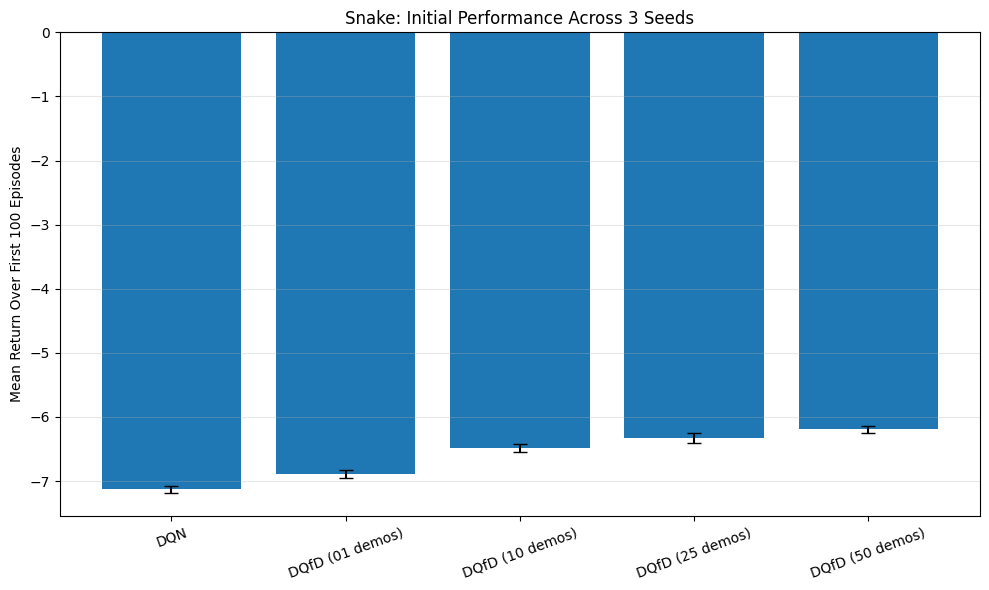

Initial performance = mean reward over first 100 episodes

DQN                | mean = -7.132 | std = 0.050 | per-seed = [-7.0620003 -7.158     -7.1759996]
DQfD (01 demos)    | mean = -6.890 | std = 0.057 | per-seed = [-6.923999  -6.8100004 -6.9360003]
DQfD (10 demos)    | mean = -6.486 | std = 0.069 | per-seed = [-6.564001  -6.4979997 -6.396    ]
DQfD (25 demos)    | mean = -6.324 | std = 0.077 | per-seed = [-6.372     -6.384     -6.2159996]
DQfD (50 demos)    | mean = -6.196 | std = 0.056 | per-seed = [-6.1980004 -6.125999  -6.2639995]


In [43]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


INITIAL_WINDOW = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """
    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    rewards_per_seed = []
    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[:max_episodes]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def compute_initial_performance_stats(rewards_per_seed, initial_window=100):
    """
    For each seed, compute the mean reward over the last `initial_window` episodes.
    Then compute mean and std across seeds.
    """
    per_seed_final_means = []

    for rewards in rewards_per_seed:
        rewards = np.asarray(rewards, dtype=np.float32)

        if len(rewards) < initial_window:
            seed_mean = np.mean(rewards)
        else:
            seed_mean = np.mean(rewards[:initial_window])

        per_seed_final_means.append(seed_mean)

    per_seed_final_means = np.asarray(per_seed_final_means, dtype=np.float32)

    return {
        "per_seed_final_means": per_seed_final_means,
        "mean": float(np.mean(per_seed_final_means)),
        "std": float(np.std(per_seed_final_means)),
    }


def plot_initial_performance_bar(
    all_rewards,
    labels,
    initial_window=100,
    ylabel="Final Average Return",
    title="Final Performance Comparison",
):
    stats = [compute_initial_performance_stats(r, initial_window=initial_window) for r in all_rewards]

    means = [s["mean"] for s in stats]
    stds = [s["std"] for s in stats]

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 6))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels, rotation=20)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Initial performance = mean reward over first {initial_window} episodes\n")
    for label, s in zip(labels, stats):
        print(f"{label:18s} | mean = {s['mean']:.3f} | std = {s['std']:.3f} | per-seed = {s['per_seed_final_means']}")


# ---------------------------------------------------------
# Snake experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_flappy_3seeds",
    "dqfd_flappy_01_3seeds",
    "dqfd_flappy_10_3seeds",
    "dqfd_flappy_25_3seeds",
    "dqfd_flappy_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load full reward curves
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=None)
    for folder in experiment_folders
]

# Plot final performance bar chart
plot_initial_performance_bar(
    all_rewards=all_rewards,
    labels=labels,
    initial_window=INITIAL_WINDOW,
    ylabel="Mean Return Over First 100 Episodes",
    title="Snake: Initial Performance Across 3 Seeds",
)

Results – Flappy Bird (Initial Performance)

In the Initial Performance plot for Flappy Bird, we can observe that during the first 100 episodes, the best results are achieved by DQfD with 50 demonstration episodes, which corresponds to the model with the largest amount of prior experience.

Then, performance generally decreases as the number of demonstrations decreases, and DQN has the worst mean return among all models.

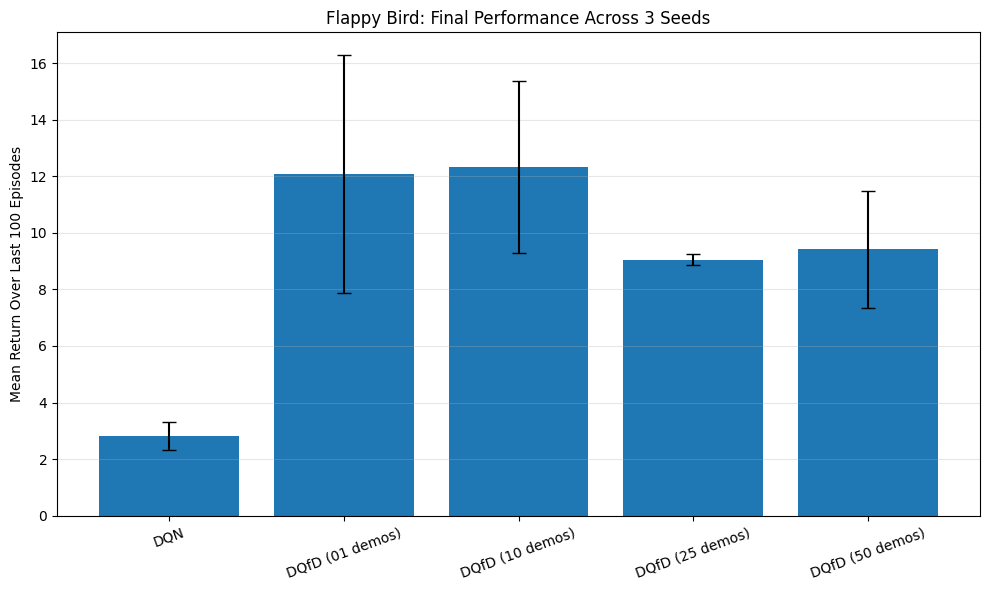

Final performance = mean reward over last 100 episodes

DQN                | mean = 2.814 | std = 0.483 | per-seed = [3.466 2.312 2.663]
DQfD (01 demos)    | mean = 12.071 | std = 4.201 | per-seed = [ 7.9540005 17.84      10.419999 ]
DQfD (10 demos)    | mean = 12.327 | std = 3.027 | per-seed = [ 8.131    13.688999 15.159999]
DQfD (25 demos)    | mean = 9.052 | std = 0.185 | per-seed = [9.194 8.791 9.172]
DQfD (50 demos)    | mean = 9.424 | std = 2.068 | per-seed = [ 8.094     12.345      7.8339996]


In [42]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


FINAL_WINDOW = 100


def load_rewards_from_results_folder(folder_path, max_episodes=None):
    """
    Load per-seed episode reward curves from a results folder containing
    training_results.pkl or dqfd_training_results.pkl.
    """
    possible_files = [
        os.path.join(folder_path, "training_results.pkl"),
        os.path.join(folder_path, "dqfd_training_results.pkl"),
    ]

    results_file = None
    for f in possible_files:
        if os.path.exists(f):
            results_file = f
            break

    if results_file is None:
        raise FileNotFoundError(
            f"No results pickle found in {folder_path}. "
            f"Expected training_results.pkl or dqfd_training_results.pkl"
        )

    with open(results_file, "rb") as f:
        results = pickle.load(f)

    rewards_per_seed = []
    for run in results["runs"]:
        rewards = run["episode_rewards"]

        if max_episodes is not None:
            rewards = rewards[:max_episodes]

        rewards_per_seed.append(rewards)

    return rewards_per_seed


def compute_final_performance_stats(rewards_per_seed, final_window=100):
    """
    For each seed, compute the mean reward over the last `final_window` episodes.
    Then compute mean and std across seeds.
    """
    per_seed_final_means = []

    for rewards in rewards_per_seed:
        rewards = np.asarray(rewards, dtype=np.float32)

        if len(rewards) < final_window:
            seed_mean = np.mean(rewards)
        else:
            seed_mean = np.mean(rewards[-final_window:])

        per_seed_final_means.append(seed_mean)

    per_seed_final_means = np.asarray(per_seed_final_means, dtype=np.float32)

    return {
        "per_seed_final_means": per_seed_final_means,
        "mean": float(np.mean(per_seed_final_means)),
        "std": float(np.std(per_seed_final_means)),
    }


def plot_final_performance_bar(
    all_rewards,
    labels,
    final_window=100,
    ylabel="Final Average Return",
    title="Final Performance Comparison",
):
    stats = [compute_final_performance_stats(r, final_window=final_window) for r in all_rewards]

    means = [s["mean"] for s in stats]
    stds = [s["std"] for s in stats]

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 6))
    plt.bar(x, means, yerr=stds, capsize=5)
    plt.xticks(x, labels, rotation=20)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Final performance = mean reward over last {final_window} episodes\n")
    for label, s in zip(labels, stats):
        print(f"{label:18s} | mean = {s['mean']:.3f} | std = {s['std']:.3f} | per-seed = {s['per_seed_final_means']}")


# ---------------------------------------------------------
# Set your experiment folders
# ---------------------------------------------------------

experiment_folders = [
    "dqn_flappy_3seeds",
    "dqfd_flappy_01_3seeds",
    "dqfd_flappy_10_3seeds",
    "dqfd_flappy_25_3seeds",
    "dqfd_flappy_50_3seeds",
]

labels = [
    "DQN",
    "DQfD (01 demos)",
    "DQfD (10 demos)",
    "DQfD (25 demos)",
    "DQfD (50 demos)",
]

# Load full reward curves
all_rewards = [
    load_rewards_from_results_folder(folder, max_episodes=None)
    for folder in experiment_folders
]

# Plot final performance bar chart
plot_final_performance_bar(
    all_rewards=all_rewards,
    labels=labels,
    final_window=FINAL_WINDOW,
    ylabel="Mean Return Over Last 100 Episodes",
    title="Flappy Bird: Final Performance Across 3 Seeds",
)

Results – Flappy Bird (Final Performance)

For the Final Performance plot of Flappy Bird, we can observe that the worst mean return is obtained by DQN. However, there does not appear to be a clear pattern among the DQfD models.

The model with the highest mean return is DQfD with 1 demonstration; however, it also exhibits the highest variance. As the number of demonstrations increases, the variance generally decreases, with the exception of the 25-demonstration setting.